# 1. Setup del entorno

In [1]:
# ========================================
# 1. LIBRERÍAS
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


# 🔷 2. Carga del dataset

Usamos el dataset de resultados internacionales directamente desde GitHub.

In [2]:
# ========================================
# 2. CARGA DE DATOS
# ========================================
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

df = pd.read_csv(url)

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (49071, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49071 non-null  object
 1   homeTeam    49071 non-null  object
 2   awayTeam    49071 non-null  object
 3   homeScore   49071 non-null  int64 
 4   awayScore   49071 non-null  int64 
 5   tournament  49071 non-null  object
 6   city        49071 non-null  object
 7   country     49071 non-null  object
 8   neutral     49071 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


# 3. Estandarización de columnas (camelCase)

In [3]:
# ========================================
# 3. RENOMBRE DE COLUMNAS
# ========================================
df.columns = [
    "date",
    "homeTeam",
    "awayTeam",
    "homeScore",
    "awayScore",
    "tournament",
    "city",
    "country",
    "neutral"
]

df.head()

,date,homeTeam,awayTeam,homeScore,awayScore,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


# 4. TIPOS DE DATOS

In [5]:
# ========================================
# 4. TIPOS DE DATOS
# ========================================
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49071 non-null  datetime64[ns]
 1   homeTeam    49071 non-null  object        
 2   awayTeam    49071 non-null  object        
 3   homeScore   49071 non-null  int64         
 4   awayScore   49071 non-null  int64         
 5   tournament  49071 non-null  object        
 6   city        49071 non-null  object        
 7   country     49071 non-null  object        
 8   neutral     49071 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.0+ MB


# 5. Creación del target (matchResult)

In [6]:
# ========================================
# 5. VARIABLE OBJETIVO
# ========================================
def getMatchResult(row):
    if row["homeScore"] > row["awayScore"]:
        return "win"
    elif row["homeScore"] < row["awayScore"]:
        return "loss"
    else:
        return "draw"

df["matchResult"] = df.apply(getMatchResult, axis=1)

df["matchResult"].value_counts(normalize=True)

matchResult
win     0.489964
loss    0.282692
draw    0.227344
Name: proportion, dtype: float64

# 6. Validación básica de calidad

In [11]:
# ========================================
# 6. CALIDAD DE DATOS
# ========================================

# Nulos
print("Valores nulos:\n", df.isnull().sum())

# Duplicados
print("\nDuplicados:", df.duplicated().sum())

# Fechas
print("\nRango de fechas:\n Desde", df["date"].min(), "→ hasta", df["date"].max())

Valores nulos:
 date           0
homeTeam       0
awayTeam       0
homeScore      0
awayScore      0
tournament     0
city           0
country        0
neutral        0
matchResult    0
dtype: int64

Duplicados: 0

Rango de fechas:
 Desde 1872-11-30 00:00:00 → hasta 2026-01-26 00:00:00


# 7. Análisis exploratorio inicial (EDA)

## Distribución de resultados

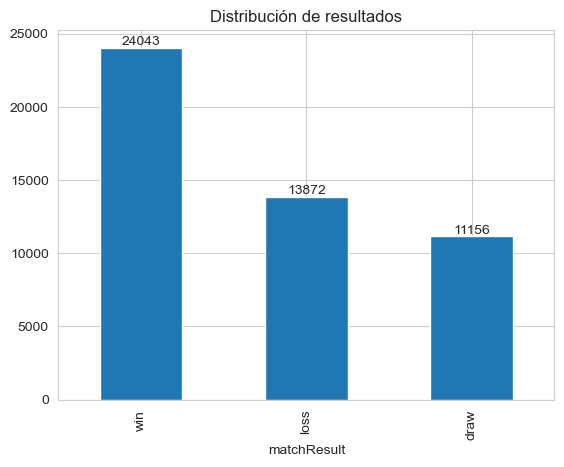

In [15]:
# ========================================
# 7. EDA - RESULTADOS
# ========================================
ax = df["matchResult"].value_counts().plot(kind="bar")
plt.title("Distribución de resultados")
# Agregar valores en las barras
for cont in ax.containers:
    ax.bar_label(cont)
plt.show()

## Goles

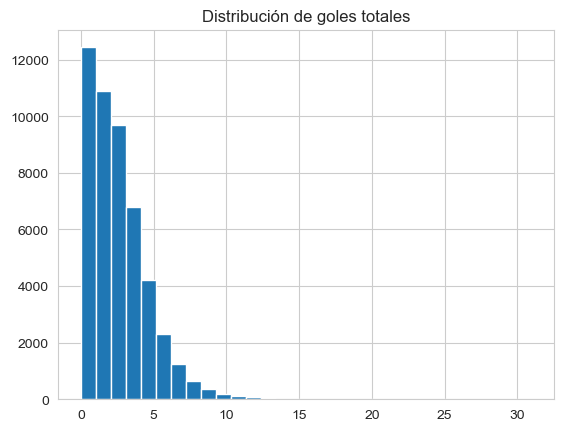

In [16]:
df["totalGoals"] = df["homeScore"] + df["awayScore"]

df["totalGoals"].hist(bins=30)
plt.title("Distribución de goles totales")
plt.show()

## Evolución en el tiempo

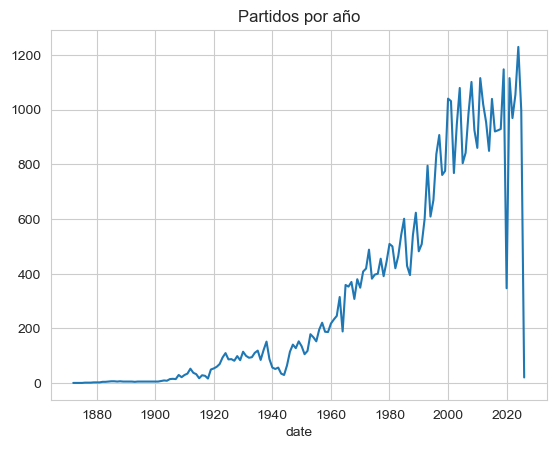

In [17]:
df.groupby(df["date"].dt.year).size().plot()
plt.title("Partidos por año")
plt.show()